## This is the first step performed by the pipeline that is data loading and converting to processable form i.e numpy array.

In [23]:
import numpy as np 
from astropy.io import fits
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
#importing the data as a list of header data units.
hdu_list_AS = fits.open("../data/raw/AS205_continuum.fits")
hdu_list_Elias = fits.open("../data/raw/Elias24_continuum.fits")
hdu_list_HD142 = fits.open("../data/raw/HD142666_continuum.fits")
hdu_list_HTLup = fits.open("../data/raw/HTLup_continuum.fits")


In [16]:
image_data1 = hdu_list_AS[0].data
image_data2 = hdu_list_Elias[0].data
image_data3 = hdu_list_HD142[0].data
image_data4 = hdu_list_HTLup[0].data

In [13]:
image_data1

array([[[[ 3.07230948e-05,  3.46398083e-05,  3.75385716e-05, ...,
           2.02125411e-05,  2.06090863e-05,  2.00882714e-05],
         [ 2.80444583e-05,  3.26931768e-05,  3.58448451e-05, ...,
           2.08750080e-05,  2.22364306e-05,  2.25006570e-05],
         [ 1.99406022e-05,  2.51733145e-05,  2.87474086e-05, ...,
           1.92393472e-05,  2.17485758e-05,  2.29388625e-05],
         ...,
         [-1.05409827e-05, -1.13704727e-05, -1.19619090e-05, ...,
           2.89483087e-05,  2.63877482e-05,  2.20993225e-05],
         [-1.18012367e-05, -1.23110340e-05, -1.29160908e-05, ...,
           3.20996187e-05,  3.03908764e-05,  2.60135348e-05],
         [-1.24783528e-05, -1.27416661e-05, -1.31182205e-05, ...,
           3.17545891e-05,  3.10375362e-05,  2.67898849e-05]]]],
      shape=(1, 1, 3000, 3000), dtype='>f4')

In [17]:
print(image_data1.shape)
print(image_data2.shape)
print(image_data3.shape)
print(image_data4.shape)

(1, 1, 3000, 3000)
(1, 1, 3000, 3000)
(1, 1, 3000, 3000)
(1, 1, 4000, 4000)


In [21]:
squeezed_data1 = np.squeeze(image_data1)
squeezed_data2 = np.squeeze(image_data2)
squeezed_data3 = np.squeeze(image_data3)
squeezed_data4 = np.squeeze(image_data4)


In [22]:
squeezed_data2.shape

(3000, 3000)

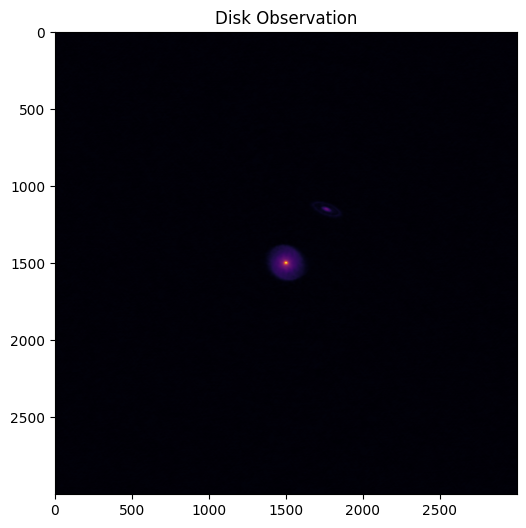

In [24]:
plt.figure(figsize=(6,6))
plt.imshow(squeezed_data1 , cmap = 'inferno')
plt.colorbar
plt.title("Disk Observation")
plt.show()

C:\Users\satna\AppData\Local\Temp\ipykernel_7140\2910603522.py:2: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(squeezed_data1 + 1e-6), cmap="inferno")


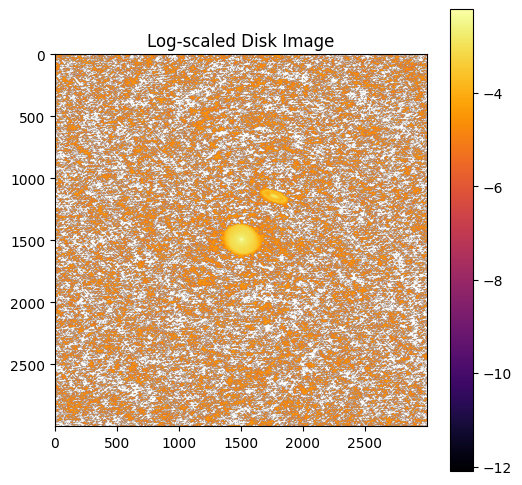

In [26]:


plt.figure(figsize=(6,6))
plt.imshow(np.log10(squeezed_data1 + 1e-6), cmap="inferno")
plt.colorbar()
plt.title("Log-scaled Disk Image")
plt.show()

C:\Users\satna\AppData\Local\Temp\ipykernel_7140\2716300979.py:9: RuntimeWarning: invalid value encountered in log10
  ax.imshow(np.log10(images[i] + 1e-6), cmap="inferno")


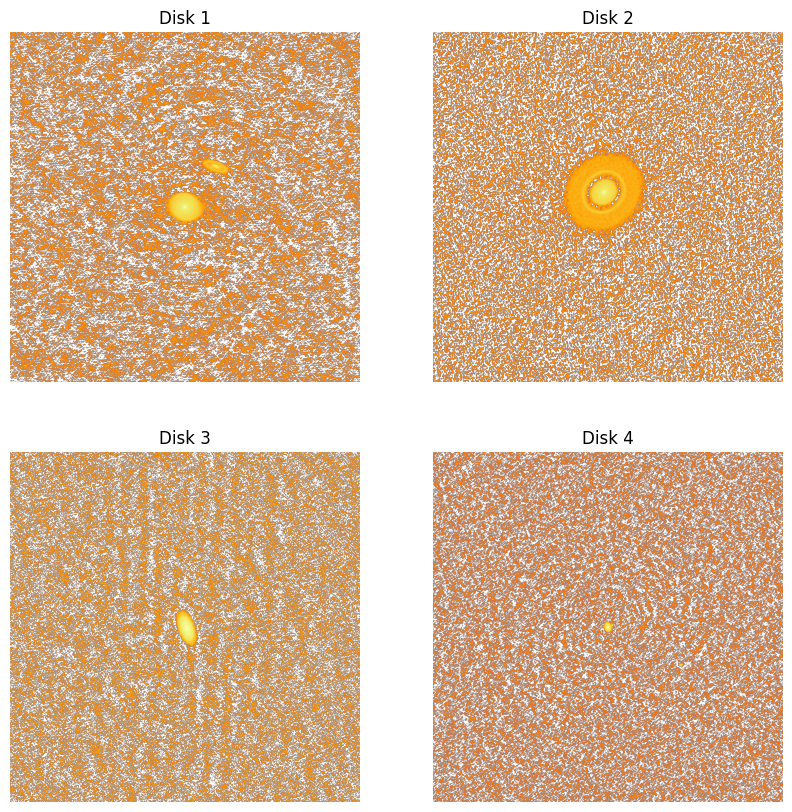

In [28]:
import matplotlib.pyplot as plt
import numpy as np

images = [squeezed_data1, squeezed_data2, squeezed_data3, squeezed_data4]

fig, axes = plt.subplots(2,2, figsize=(10,10))

for i, ax in enumerate(axes.flat):
    ax.imshow(np.log10(images[i] + 1e-6), cmap="inferno")
    ax.set_title(f"Disk {i+1}")
    ax.axis("off")

plt.show()

In [32]:
h, w = squeezed_data1.shape

center_x = w // 2
center_y = h // 2

In [33]:
size = 512
half = size // 2

cropped = squeezed_data1[
    center_y-half:center_y+half,
    center_x-half:center_x+half
]

In [34]:
print(cropped.shape)

(512, 512)


C:\Users\satna\AppData\Local\Temp\ipykernel_7140\1809152666.py:1: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(cropped + 1e-6), cmap="inferno")


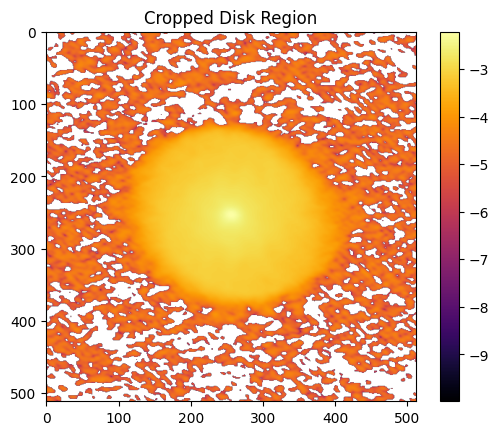

In [35]:
plt.imshow(np.log10(cropped + 1e-6), cmap="inferno")
plt.colorbar()
plt.title("Cropped Disk Region")
plt.show()

In [36]:
print(cropped.min())
print(cropped.max())

-7.7183744e-05
0.006149446


In [38]:
min_val = squeezed_data1.min()
max_val = squeezed_data1.max()

normalised = (squeezed_data1 - min_val) / (max_val - min_val)

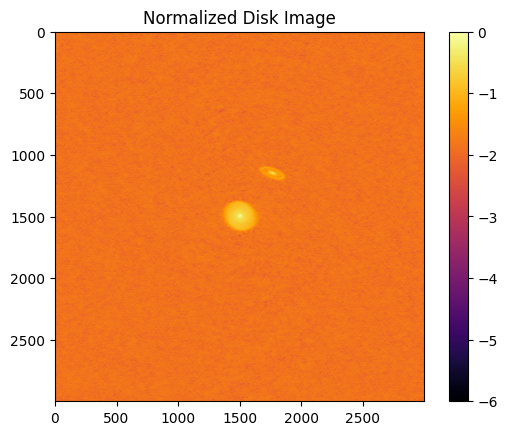

In [41]:
plt.imshow(np.log10(normalised + 1e-6), cmap="inferno")
plt.colorbar()
plt.title("Normalized Disk Image")
plt.show()